In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import sys
sys.path.append('/content/drive/MyDrive/ML_Final_Project')

In [26]:
!cp /content/drive/MyDrive/ML_Final_Project/eval128.zip /content/
!unzip -q /content/eval128.zip -d /content/preprocessed
print("Done!")

Done!


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import roc_curve, auc as sklearn_auc
from scipy.stats import norm
from sklearn.metrics import label_ranking_average_precision_score
import io
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
import time
import os

from fsd50k_setup_cl128 import (
    train_loader, val_loader, eval_loader,
    NUM_CLASSES, decode_labels, encode_labels,
    FRAME_COUNT, vocab, top_level, get_top_level_family
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cuda device


In [38]:
## CNN model definition (from training notebook)

class AudioCNN(nn.Module):
    """
    Four convolutional blocks followed by global average pooling
    and a linear classifier.

    Each block:
        Conv2d → BatchNorm → ReLU → MaxPool """


    def __init__(self, num_classes: int = 200): #dim comments assumes N_mels = 128
        super().__init__()

        self.features = nn.Sequential(
            # Block 1 — learns low-level features (edges in freq/time)
            # Input:  (batch, 1,   128, 516)
            # Output: (batch, 32,  64,  258)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2 — learns mid-level patterns (harmonics, rhythms)
            # Input:  (batch, 32,  64,  258)
            # Output: (batch, 64,  32,  129)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3 — learns higher-level combinations
            # Input:  (batch, 64,  32,  129)
            # Output: (batch, 128, 16, 64)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4 — learns abstract sound representations
            # Input:  (batch, 128, 16,  64)
            # Output: (batch, 128, 8,   32)
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.gap = nn.AdaptiveAvgPool2d((4, 4))  #(batch, 128, 8, 32) → (batch, 128, 4, 4)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(128 * 4 * 4, 512), nn.ReLU(),
                                      nn.Dropout(0.3), nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.2),
                                      nn.Linear(256, num_classes))

    def forward(self, x):
      x = self.features(x)    # (batch, 128, 8, 32)
      x = self.gap(x)         # (batch, 128, 4, 4)
      x = x.flatten(1)        # (batch, 2048)
      x = self.classifier(x)  # (batch, 200)
      return x

full_model_9: Oversampling only

full_model_10: Focal loss + bias initilization

full_model_12: Baseline

full_model_13: Oversampling + spec augmentation + mixup augmentation

In [39]:
oversample_only_model = AudioCNN(num_classes=NUM_CLASSES).to(device)
oversample_only_model.load_state_dict(torch.load("/content/drive/MyDrive/ML_Final_Project/full_model_9.pt", map_location=device))

focalloss_bias_model = AudioCNN(num_classes=NUM_CLASSES).to(device)
focalloss_bias_model.load_state_dict(torch.load("/content/drive/MyDrive/ML_Final_Project/full_model_10.pt", map_location=device))

baseline_model = AudioCNN(num_classes=NUM_CLASSES).to(device)
baseline_model.load_state_dict(torch.load("/content/drive/MyDrive/ML_Final_Project/full_model_12.pt", map_location=device))

oversample_specaug_mixaug_model = AudioCNN(num_classes=NUM_CLASSES).to(device)
oversample_specaug_mixaug_model.load_state_dict(torch.load("/content/drive/MyDrive/ML_Final_Project/full_model_13.pt", map_location=device))

<All keys matched successfully>

In [50]:
def evaluate_families(loader, model):
    model.eval()
    all_labels, all_probs = [], []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device, non_blocking=True)
            labels   = labels.to(device, non_blocking=True)
            logits   = model(features)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs  = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    families = list(top_level.values())  # 6 families
    n_clips  = len(all_labels)

    # Build family-level true labels and predicted scores
    true_family  = np.zeros((n_clips, len(families)))
    pred_family  = np.zeros((n_clips, len(families)))

    for i in range(n_clips):
        # True: which families are active for this clip
        true_indices = all_labels[i].nonzero()[0]
        for idx in true_indices:
            fam = get_top_level_family(vocab.iloc[idx]["mid"])
            if fam in families:
                true_family[i, families.index(fam)] = 1.0

        # Predicted: max prob per family
        for j, fam in enumerate(families):
            fam_indices = [k for k in range(200) if get_top_level_family(vocab.iloc[k]["mid"]) == fam]
            if fam_indices:
                pred_family[i, j] = all_probs[i, fam_indices].max()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UndefinedMetricWarning)
        mAP_overall = average_precision_score(true_family, pred_family, average="macro")
        mAP_per_fam = average_precision_score(true_family, pred_family, average=None)

    print(f"Overall family mAP: {mAP_overall:.3f}\n")
    for fam, score in zip(families, mAP_per_fam):
        print(f"  {fam:<30} {score:.3f}")

    return mAP_overall, dict(zip(families, mAP_per_fam))

def evaluate_metrics(loader, model):
    model.eval()
    all_labels, all_probs = [], []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device, non_blocking=True)
            labels   = labels.to(device, non_blocking=True)
            logits   = model(features)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs  = np.vstack(all_probs)   # (N, 200)
    all_labels = np.vstack(all_labels)  # (N, 200)

    # mAP
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UndefinedMetricWarning)
        mAP = average_precision_score(all_labels, all_probs, average="macro")

    # AUC per class → d-prime
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        auc_per_class = roc_auc_score(all_labels, all_probs, average=None)
    auc  = float(np.mean(auc_per_class))
    dprime = float(np.mean(norm.ppf(auc_per_class.clip(1e-7, 1 - 1e-7)) * np.sqrt(2)))

    # lwlrap — skip clips with no positive labels
    sample_weight = np.sum(all_labels > 0, axis=1)
    nonzero       = np.flatnonzero(sample_weight > 0)
    lwlrap = label_ranking_average_precision_score(
        all_labels[nonzero] > 0,
        all_probs[nonzero],
        sample_weight=sample_weight[nonzero]
    )

    # ROC curves
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(NUM_CLASSES):
      fpr[i], tpr[i], _ = roc_curve(all_labels[:, i], all_probs[:, i])
      roc_auc[i] = sklearn_auc(fpr[i], tpr[i])

    return mAP, dprime, lwlrap, roc_auc, fpr, tpr

In [41]:
metrics_baseline = evaluate_metrics(eval_loader, baseline_model)
families_baseline = evaluate_families(eval_loader, baseline_model)

Overall family mAP: 0.747

  Human sounds                   0.834
  Animal                         0.703
  Music                          0.884
  Natural sounds                 0.669
  Sounds of things               0.877
  Source-ambiguous sounds        0.517


In [51]:
metrics_oversample = evaluate_metrics(eval_loader, oversample_only_model)
metrics_focalloss = evaluate_metrics(eval_loader, focalloss_bias_model)
metrics_specaug_mixaug = evaluate_metrics(eval_loader, oversample_specaug_mixaug_model)

In [43]:
families_oversample = evaluate_families(eval_loader, oversample_only_model)
families_focalloss = evaluate_families(eval_loader, focalloss_bias_model)
families_specaug_mixaug = evaluate_families(eval_loader, oversample_specaug_mixaug_model)

Overall family mAP: 0.739

  Human sounds                   0.829
  Animal                         0.694
  Music                          0.875
  Natural sounds                 0.659
  Sounds of things               0.883
  Source-ambiguous sounds        0.494
Overall family mAP: 0.745

  Human sounds                   0.834
  Animal                         0.697
  Music                          0.889
  Natural sounds                 0.662
  Sounds of things               0.879
  Source-ambiguous sounds        0.512
Overall family mAP: 0.754

  Human sounds                   0.846
  Animal                         0.710
  Music                          0.889
  Natural sounds                 0.661
  Sounds of things               0.893
  Source-ambiguous sounds        0.527


In [46]:
#print mAP values for all
mAPs = [metrics_baseline[0], metrics_oversample[0], metrics_focalloss[0], metrics_specaug_mixaug[0]]
for i, mAP in enumerate(mAPs):
  print(f"Model {i+1} mAP: {mAP:.3f}")

Model 1 mAP: 0.443
Model 2 mAP: 0.439
Model 3 mAP: 0.440
Model 4 mAP: 0.470


In [47]:
#print d' scores for all
d_prime = [metrics_baseline[1], metrics_oversample[1], metrics_focalloss[1], metrics_specaug_mixaug[1]]
for i, d in enumerate(d_prime):
  print(f"Model {i+1} d' score: {d:.3f}")

Model 1 d' score: 2.273
Model 2 d' score: 2.247
Model 3 d' score: 2.292
Model 4 d' score: 2.309


In [49]:
#print lwlrap for all
lwlraps = [metrics_baseline[2], metrics_oversample[2], metrics_focalloss[2], metrics_specaug_mixaug[2]]
for i in range(len(lwlraps)):
  print(f"Model {i+1} lwlrap: {lwlraps[i]:.3f}")
#

Model 1 lwlrap: 0.633
Model 2 lwlrap: 0.625
Model 3 lwlrap: 0.629
Model 4 lwlrap: 0.643


In [54]:
def plot_top5_roc(loader, model, vocab):
    _, _, _, roc_auc, fpr, tpr = evaluate_metrics(loader, model)

    # Get top 5 class indices by AUC score
    top5_indices = sorted(roc_auc, key=roc_auc.get, reverse=True)[:5]

    fig, ax = plt.subplots(figsize=(8, 6))

    for i in top5_indices:
        label_name = vocab.iloc[i]["label_name"]
        ax.plot(fpr[i], tpr[i], lw=2,
                label=f"{label_name} (AUC = {roc_auc[i]:.3f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves – Top 5 Labels by AUC")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("top5_roc.png", dpi=150)
    plt.show()

In [56]:
def plot_bottom5_roc(loader, model, vocab):
    _, _, _, roc_auc, fpr, tpr = evaluate_metrics(loader, model)

    # Get top 5 class indices by AUC score
    top5_indices = sorted(roc_auc, key=roc_auc.get)[:5]

    fig, ax = plt.subplots(figsize=(8, 6))

    for i in top5_indices:
        label_name = vocab.iloc[i]["label_name"]
        ax.plot(fpr[i], tpr[i], lw=2,
                label=f"{label_name} (AUC = {roc_auc[i]:.3f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves – Bottom 5 Labels by AUC")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("top5_roc.png", dpi=150)
    plt.show()

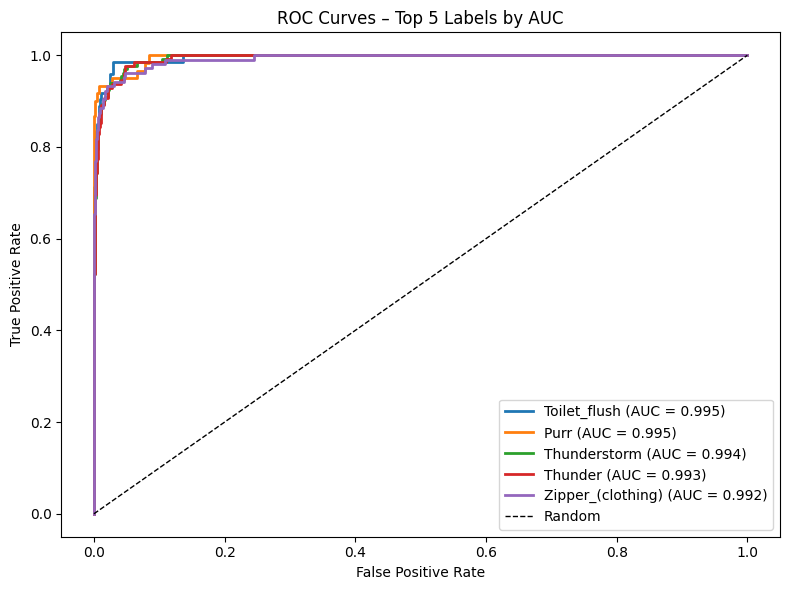

In [55]:
#plot roc curves for top 5 labels model 4

plot_top5_roc(eval_loader, oversample_specaug_mixaug_model, vocab)


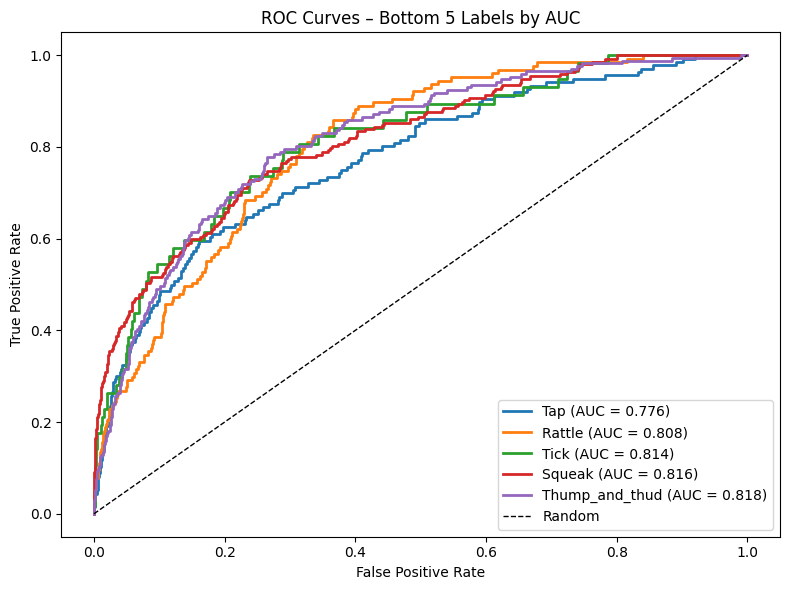

In [57]:
plot_bottom5_roc(eval_loader, oversample_specaug_mixaug_model, vocab)
